# Chapter 8.1: Embedding Tables at Scale

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain why recommendation models have trillion-parameter embedding tables and what makes them so large
2. Describe Meta's DLRM architecture and its interaction between sparse and dense features
3. Implement and compare row-wise, column-wise, and table-wise embedding partitioning strategies
4. Understand the memory hierarchy for embedding lookup (GPU HBM, CPU DRAM, SSD)
5. Apply tensor-train decomposition (TT-Rec) for embedding table compression
6. Describe Kraken, Meta's distributed embedding system for production-scale recommendation
7. Simulate a large-scale embedding system with different partitioning strategies

## Prerequisites

- Familiarity with PyTorch and `nn.Embedding`
- Understanding of recommendation system basics (Part 1)
- Basic knowledge of distributed computing concepts

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part8/chapter_8.1_embedding_scale.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part8/chapter_8.1_embedding_scale.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Use a style that works across matplotlib versions
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        pass  # Use default style

print(f"PyTorch version: {torch.__version__}")
print(f"Device: CPU (simulating distributed embedding systems)")

PyTorch version: 2.2.2
Device: CPU (simulating distributed embedding systems)


## 1. Why Recommendation Models Are So Large

Modern industrial recommendation systems routinely work with **trillions of parameters**, dwarfing even the largest language models. The reason is simple: **embedding tables**.

Consider a typical e-commerce system:
- User IDs: 1 billion users x 128-dim embedding = **512 GB**
- Item IDs: 100 million items x 128-dim embedding = **51.2 GB**
- Cross features (user x item category, user x brand, etc.): can easily reach **TBs**

Each categorical feature gets its own embedding table:

$$\text{Memory} = \sum_{i=1}^{N_{\text{tables}}} |V_i| \times d_i \times \text{bytes\_per\_param}$$

where $|V_i|$ is the vocabulary size and $d_i$ is the embedding dimension for the $i$-th table.

> **\U0001f4a1 Concept:** Unlike language models where parameters are in dense weight matrices, rec model parameters are overwhelmingly in **sparse embedding tables**. This means most parameters are accessed rarely -- a given user ID is looked up only when that user visits.

In [2]:
# Let's compute the memory requirements for a realistic recommendation system

@dataclass
class EmbeddingTableConfig:
    name: str
    vocab_size: int
    embedding_dim: int
    
    @property
    def memory_bytes(self) -> int:
        return self.vocab_size * self.embedding_dim * 4  # float32
    
    @property
    def memory_gb(self) -> float:
        return self.memory_bytes / (1024**3)
    
    @property
    def num_params(self) -> int:
        return self.vocab_size * self.embedding_dim

# Realistic embedding table sizes for a large-scale recommendation system
tables = [
    EmbeddingTableConfig("user_id", 1_000_000_000, 128),
    EmbeddingTableConfig("item_id", 100_000_000, 128),
    EmbeddingTableConfig("user_x_category", 500_000_000, 64),
    EmbeddingTableConfig("brand", 10_000_000, 64),
    EmbeddingTableConfig("category", 50_000, 64),
    EmbeddingTableConfig("city", 100_000, 32),
    EmbeddingTableConfig("device_type", 1000, 16),
    EmbeddingTableConfig("query_token", 5_000_000, 64),
    EmbeddingTableConfig("user_x_brand", 200_000_000, 64),
    EmbeddingTableConfig("historical_item_seq", 100_000_000, 128),
]

total_params = sum(t.num_params for t in tables)
total_memory = sum(t.memory_gb for t in tables)

print("Embedding Table Memory Requirements")
print("=" * 65)
print(f"{'Table':<25} {'Vocab Size':>15} {'Dim':>5} {'Memory (GB)':>12}")
print("-" * 65)
for t in tables:
    print(f"{t.name:<25} {t.vocab_size:>15,} {t.embedding_dim:>5} {t.memory_gb:>12.2f}")
print("-" * 65)
print(f"{'TOTAL':<25} {'':<15} {'':<5} {total_memory:>12.2f}")
print(f"\nTotal parameters: {total_params/1e12:.2f} trillion")
print(f"Total memory (FP32): {total_memory:.1f} GB")
print(f"\nFor comparison, GPT-3 has 0.175 trillion parameters")

Embedding Table Memory Requirements
Table                          Vocab Size   Dim  Memory (GB)
-----------------------------------------------------------------
user_id                     1,000,000,000   128       476.84
item_id                       100,000,000   128        47.68
user_x_category               500,000,000    64       119.21
brand                          10,000,000    64         2.38
category                           50,000    64         0.01
city                              100,000    32         0.01
device_type                         1,000    16         0.00
query_token                     5,000,000    64         1.19
user_x_brand                  200,000,000    64        47.68
historical_item_seq           100,000,000   128        47.68
-----------------------------------------------------------------
TOTAL                                                 742.70

Total parameters: 0.20 trillion
Total memory (FP32): 742.7 GB

For comparison, GPT-3 has 0.175 tril

## 2. Meta's DLRM Architecture

The **Deep Learning Recommendation Model (DLRM)** (Naumov et al., Meta, 2019) is the foundational architecture for industrial-scale recommendation. It cleanly separates:

- **Sparse features**: Categorical features (user ID, item ID, etc.) processed through embedding tables
- **Dense features**: Numerical features (age, price, etc.) processed through a bottom MLP

The architecture:

$$\text{sparse\_out}_i = \text{EmbeddingLookup}_i(x_i^{\text{sparse}})$$

$$\text{dense\_out} = \text{BottomMLP}(x^{\text{dense}})$$

$$\text{interactions} = \text{FeatureInteraction}([\text{dense\_out}, \text{sparse\_out}_1, \ldots, \text{sparse\_out}_k])$$

$$\hat{y} = \text{TopMLP}(\text{concat}(\text{dense\_out}, \text{interactions}))$$

> **\u26a0\ufe0f Common Pitfall:** The embedding lookups in DLRM are **memory-bound**, not compute-bound. The bottleneck is fetching embeddings from memory, not matrix multiplication. This is fundamentally different from language model training.

In [3]:
class DLRM(nn.Module):
    """Simplified Deep Learning Recommendation Model (Meta, 2019)."""
    
    def __init__(
        self,
        embedding_configs: List[Tuple[int, int]],  # (vocab_size, emb_dim)
        dense_input_dim: int,
        bottom_mlp_dims: List[int],
        top_mlp_dims: List[int],
        interaction_type: str = "dot",
    ):
        super().__init__()
        
        # Sparse feature embeddings
        self.embeddings = nn.ModuleList([
            nn.EmbeddingBag(vocab, dim, mode='sum')
            for vocab, dim in embedding_configs
        ])
        
        # Bottom MLP for dense features
        emb_dim = embedding_configs[0][1]  # All embeddings output same dim
        bottom_layers = []
        prev_dim = dense_input_dim
        for dim in bottom_mlp_dims:
            bottom_layers.extend([nn.Linear(prev_dim, dim), nn.ReLU()])
            prev_dim = dim
        # Final bottom MLP layer matches embedding dim
        bottom_layers.append(nn.Linear(prev_dim, emb_dim))
        self.bottom_mlp = nn.Sequential(*bottom_layers)
        
        # Top MLP
        num_features = len(embedding_configs) + 1  # +1 for dense
        if interaction_type == "dot":
            interaction_dim = num_features * (num_features - 1) // 2 + emb_dim
        else:
            interaction_dim = num_features * emb_dim
        
        top_layers = []
        prev_dim = interaction_dim
        for dim in top_mlp_dims:
            top_layers.extend([nn.Linear(prev_dim, dim), nn.ReLU()])
            prev_dim = dim
        top_layers.append(nn.Linear(prev_dim, 1))
        self.top_mlp = nn.Sequential(*top_layers)
        
        self.interaction_type = interaction_type
        
    def interact_features(self, features: List[torch.Tensor]) -> torch.Tensor:
        """Compute pairwise dot-product interactions."""
        # Stack: (batch, num_features, emb_dim)
        x = torch.stack(features, dim=1)
        
        if self.interaction_type == "dot":
            # Pairwise dot products
            interactions = torch.bmm(x, x.transpose(1, 2))
            # Extract upper triangle (excluding diagonal)
            batch_size = x.size(0)
            num_features = x.size(1)
            triu_indices = torch.triu_indices(num_features, num_features, offset=1)
            flat_interactions = interactions[:, triu_indices[0], triu_indices[1]]
            # Concat with dense output
            return torch.cat([features[0], flat_interactions], dim=1)
        else:
            return x.reshape(x.size(0), -1)
    
    def forward(
        self,
        dense_features: torch.Tensor,
        sparse_indices: List[torch.Tensor],
        sparse_offsets: List[torch.Tensor],
    ) -> torch.Tensor:
        # Dense path
        dense_out = self.bottom_mlp(dense_features)
        
        # Sparse path
        sparse_outs = [
            emb(idx, off)
            for emb, idx, off in zip(self.embeddings, sparse_indices, sparse_offsets)
        ]
        
        # Interaction
        all_features = [dense_out] + sparse_outs
        interaction_out = self.interact_features(all_features)
        
        # Top MLP
        logit = self.top_mlp(interaction_out)
        return torch.sigmoid(logit).squeeze(-1)

# Create a small DLRM for demonstration
emb_dim = 16
embedding_configs = [
    (10000, emb_dim),   # user_id
    (5000, emb_dim),    # item_id
    (100, emb_dim),     # category
    (50, emb_dim),      # brand
]

model = DLRM(
    embedding_configs=embedding_configs,
    dense_input_dim=8,
    bottom_mlp_dims=[32, 16],
    top_mlp_dims=[64, 32],
    interaction_type="dot",
)

# Generate synthetic batch
batch_size = 32
dense = torch.randn(batch_size, 8)
sparse_idx = [torch.randint(0, vc, (batch_size,)) for vc, _ in embedding_configs]
sparse_off = [torch.arange(batch_size, dtype=torch.long) for _ in embedding_configs]

# Forward pass
with torch.no_grad():
    preds = model(dense, sparse_idx, sparse_off)
    
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
emb_params = sum(v * d for v, d in embedding_configs)
total_params = sum(p.numel() for p in model.parameters())
print(f"Embedding parameters: {emb_params:,} ({100*emb_params/total_params:.1f}% of total)")
print(f"Prediction shape: {preds.shape}, range: [{preds.min():.3f}, {preds.max():.3f}]")

Model parameters: 247,329
Embedding parameters: 242,400 (98.0% of total)
Prediction shape: torch.Size([32]), range: [0.537, 0.658]


## 3. Embedding Table Partitioning Strategies

When embedding tables exceed the memory of a single device, we must **partition** them across multiple devices. There are three main strategies:

### Row-wise Partitioning
Rows (individual embeddings) are split across devices. If vocabulary size is $V$ and we have $K$ devices:

$$\text{Device } k \text{ stores rows } [k \cdot V/K, (k+1) \cdot V/K)$$

### Column-wise Partitioning
Each embedding vector is split across devices along the dimension axis:

$$\text{Device } k \text{ stores columns } [k \cdot d/K, (k+1) \cdot d/K)$$

### Table-wise Partitioning
Entire tables are assigned to different devices:

$$\text{Device } k \text{ stores tables } \{T_i : \text{assign}(T_i) = k\}$$

> **\U0001f511 Pro Tip:** In practice, systems use a **hybrid** approach. Small tables are replicated on every device. Large tables use row-wise or column-wise sharding. Table-wise partitioning helps balance load across devices.

In [4]:
class RowWiseShardedEmbedding:
    """Simulates row-wise partitioned embedding across multiple devices."""
    
    def __init__(self, vocab_size: int, embedding_dim: int, num_shards: int):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.num_shards = num_shards
        self.shard_size = (vocab_size + num_shards - 1) // num_shards
        
        # Each shard holds a portion of the rows
        self.shards = [
            nn.Embedding(
                min(self.shard_size, vocab_size - i * self.shard_size),
                embedding_dim
            )
            for i in range(num_shards)
            if i * self.shard_size < vocab_size
        ]
        
    def lookup(self, indices: torch.Tensor) -> torch.Tensor:
        """Look up embeddings, routing to correct shard."""
        results = torch.zeros(indices.shape[0], self.embedding_dim)
        
        for i, shard in enumerate(self.shards):
            start = i * self.shard_size
            end = start + shard.num_embeddings
            mask = (indices >= start) & (indices < end)
            if mask.any():
                local_idx = indices[mask] - start
                results[mask] = shard(local_idx)
        
        return results
    
    def memory_per_shard(self) -> List[float]:
        return [s.weight.numel() * 4 / (1024**2) for s in self.shards]  # MB


class ColumnWiseShardedEmbedding:
    """Simulates column-wise partitioned embedding."""
    
    def __init__(self, vocab_size: int, embedding_dim: int, num_shards: int):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.num_shards = num_shards
        self.shard_dim = embedding_dim // num_shards
        
        self.shards = [
            nn.Embedding(vocab_size, self.shard_dim)
            for _ in range(num_shards)
        ]
    
    def lookup(self, indices: torch.Tensor) -> torch.Tensor:
        """Look up from all shards and concatenate."""
        parts = [shard(indices) for shard in self.shards]
        return torch.cat(parts, dim=-1)
    
    def memory_per_shard(self) -> List[float]:
        return [s.weight.numel() * 4 / (1024**2) for s in self.shards]  # MB


class TableWiseShardedSystem:
    """Simulates table-wise partitioning of multiple embedding tables."""
    
    def __init__(
        self, 
        table_configs: List[Tuple[str, int, int]],  # (name, vocab, dim)
        num_devices: int
    ):
        self.num_devices = num_devices
        self.table_configs = table_configs
        
        # Greedy assignment: assign tables to least-loaded device
        device_memory = [0.0] * num_devices
        self.assignment = {}
        self.tables = {}
        
        # Sort tables by size (largest first) for better balancing
        sorted_tables = sorted(table_configs, key=lambda x: x[1] * x[2], reverse=True)
        
        for name, vocab, dim in sorted_tables:
            # Assign to device with least memory usage
            target_device = min(range(num_devices), key=lambda d: device_memory[d])
            self.assignment[name] = target_device
            self.tables[name] = nn.Embedding(min(vocab, 100000), dim)  # cap for demo
            device_memory[target_device] += vocab * dim * 4 / (1024**3)  # GB
        
        self.device_memory = device_memory

# Demonstrate partitioning
vocab_size = 100000
emb_dim = 64
num_shards = 4

row_sharded = RowWiseShardedEmbedding(vocab_size, emb_dim, num_shards)
col_sharded = ColumnWiseShardedEmbedding(vocab_size, emb_dim, num_shards)

# Test lookup
test_indices = torch.randint(0, vocab_size, (16,))
row_result = row_sharded.lookup(test_indices)
col_result = col_sharded.lookup(test_indices)

print("Row-wise sharding:")
print(f"  Shards: {num_shards}, Memory per shard: {row_sharded.memory_per_shard()} MB")
print(f"  Output shape: {row_result.shape}")

print(f"\nColumn-wise sharding:")
print(f"  Shards: {num_shards}, Memory per shard: {col_sharded.memory_per_shard()} MB")
print(f"  Output shape: {col_result.shape}")

Row-wise sharding:
  Shards: 4, Memory per shard: [6.103515625, 6.103515625, 6.103515625, 6.103515625] MB
  Output shape: torch.Size([16, 64])

Column-wise sharding:
  Shards: 4, Memory per shard: [6.103515625, 6.103515625, 6.103515625, 6.103515625] MB
  Output shape: torch.Size([16, 64])


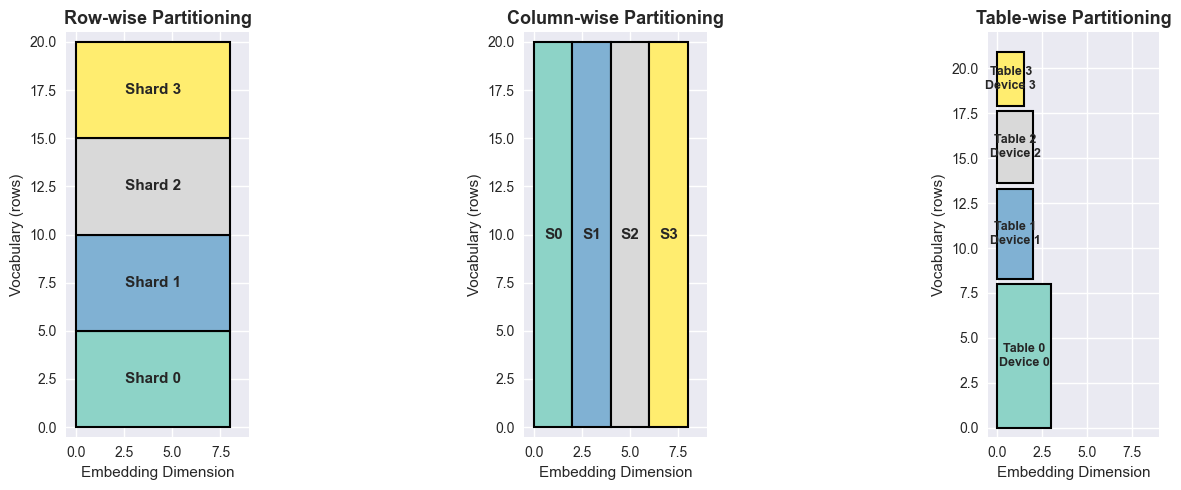

In [5]:
# Visualize partitioning strategies
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Row-wise
ax = axes[0]
colors = plt.cm.Set3(np.linspace(0, 1, 4))
rows_per_shard = 5
for i in range(4):
    rect = plt.Rectangle((0, i * rows_per_shard), 8, rows_per_shard,
                          facecolor=colors[i], edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(4, i * rows_per_shard + rows_per_shard/2, f'Shard {i}',
            ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, 9)
ax.set_ylim(-0.5, 20.5)
ax.set_xlabel('Embedding Dimension', fontsize=11)
ax.set_ylabel('Vocabulary (rows)', fontsize=11)
ax.set_title('Row-wise Partitioning', fontsize=13, fontweight='bold')
ax.set_aspect('equal')

# Column-wise
ax = axes[1]
cols_per_shard = 2
for i in range(4):
    rect = plt.Rectangle((i * cols_per_shard, 0), cols_per_shard, 20,
                          facecolor=colors[i], edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(i * cols_per_shard + cols_per_shard/2, 10, f'S{i}',
            ha='center', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(-0.5, 9)
ax.set_ylim(-0.5, 20.5)
ax.set_xlabel('Embedding Dimension', fontsize=11)
ax.set_ylabel('Vocabulary (rows)', fontsize=11)
ax.set_title('Column-wise Partitioning', fontsize=13, fontweight='bold')
ax.set_aspect('equal')

# Table-wise
ax = axes[2]
table_heights = [8, 5, 4, 3]
table_widths = [3, 2, 2, 1.5]
y_pos = 0
for i, (h, w) in enumerate(zip(table_heights, table_widths)):
    rect = plt.Rectangle((0, y_pos), w, h,
                          facecolor=colors[i], edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(w/2, y_pos + h/2, f'Table {i}\nDevice {i}',
            ha='center', va='center', fontsize=9, fontweight='bold')
    y_pos += h + 0.3
ax.set_xlim(-0.5, 9)
ax.set_ylim(-0.5, 22)
ax.set_xlabel('Embedding Dimension', fontsize=11)
ax.set_ylabel('Vocabulary (rows)', fontsize=11)
ax.set_title('Table-wise Partitioning', fontsize=13, fontweight='bold')
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('embedding_partitioning.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Memory Hierarchy for Embedding Lookup

In production systems, embeddings are stored across a memory hierarchy:

| Tier | Storage | Capacity | Bandwidth | Latency |
|------|---------|----------|-----------|----------|
| GPU HBM | High Bandwidth Memory | 40-80 GB | ~2 TB/s | ~ns |
| CPU DRAM | Main Memory | 256 GB-2 TB | ~100 GB/s | ~100ns |
| SSD/NVMe | Flash Storage | 1-16 TB | ~7 GB/s | ~10us |

**Hot embeddings** (frequently accessed) are cached in GPU HBM, while **cold embeddings** (rarely accessed) live on SSD.

This follows a power-law distribution: a small fraction of embeddings accounts for most lookups.

> **\U0001f4a1 Concept:** Meta's system (described in RecSSD, ASPLOS 2020) uses SSDs to store cold embeddings, reducing cost by 10x compared to all-DRAM solutions. The key insight: recommendation access patterns follow Zipf's law.

Memory Hierarchy Simulation Results
Total lookups: 128,000

Tier Distribution:
  GPU HBM: 85.28%
  CPU DRAM: 9.44%
  SSD: 5.29%

Average lookup latency: 0.5391 us


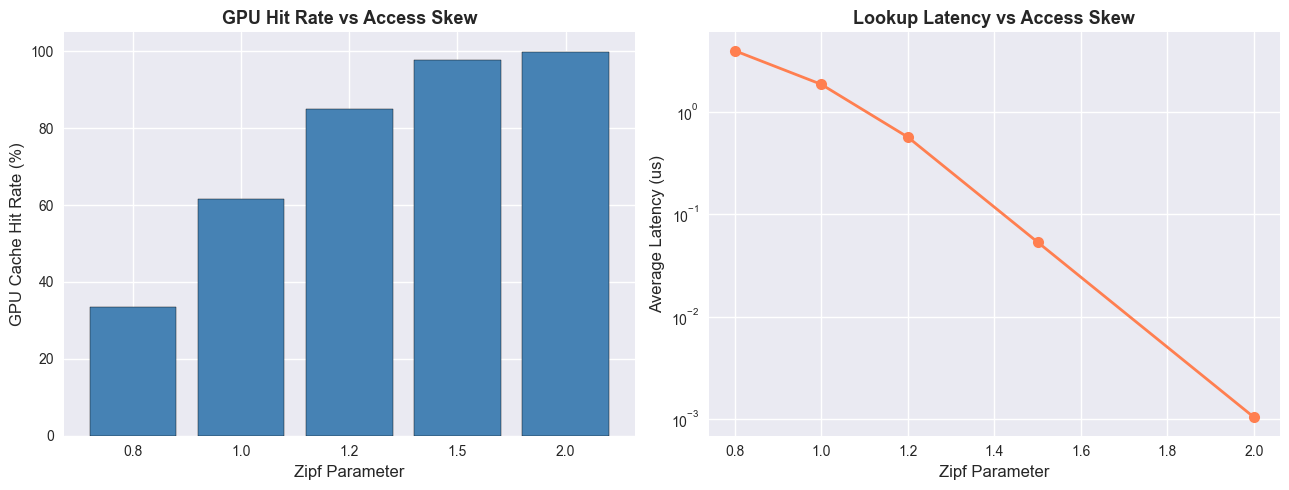

In [6]:
class MemoryHierarchySimulator:
    """Simulates tiered memory for embedding storage."""
    
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        gpu_capacity_rows: int,
        cpu_capacity_rows: int,
        zipf_param: float = 1.2,
    ):
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.gpu_capacity = gpu_capacity_rows
        self.cpu_capacity = cpu_capacity_rows
        
        # Generate access frequency following Zipf's law
        ranks = np.arange(1, vocab_size + 1)
        self.access_freq = 1.0 / np.power(ranks, zipf_param)
        self.access_freq /= self.access_freq.sum()
        
        # Assign tiers based on frequency
        sorted_idx = np.argsort(-self.access_freq)
        self.tier = np.zeros(vocab_size, dtype=int)  # 0=GPU, 1=CPU, 2=SSD
        self.tier[sorted_idx[gpu_capacity_rows:gpu_capacity_rows + cpu_capacity_rows]] = 1
        self.tier[sorted_idx[gpu_capacity_rows + cpu_capacity_rows:]] = 2
        
        # Latencies in microseconds
        self.tier_latency = {0: 0.001, 1: 0.1, 2: 10.0}
        self.tier_names = {0: 'GPU HBM', 1: 'CPU DRAM', 2: 'SSD'}
        
    def simulate_batch_lookup(self, batch_size: int, num_batches: int = 1000):
        """Simulate batch lookups and measure latency."""
        tier_counts = {0: 0, 1: 0, 2: 0}
        total_latency = 0.0
        
        for _ in range(num_batches):
            indices = np.random.choice(self.vocab_size, size=batch_size, p=self.access_freq)
            tiers = self.tier[indices]
            
            for t in range(3):
                count = np.sum(tiers == t)
                tier_counts[t] += count
                total_latency += count * self.tier_latency[t]
        
        total_lookups = sum(tier_counts.values())
        return {
            'tier_distribution': {self.tier_names[t]: tier_counts[t]/total_lookups 
                                  for t in range(3)},
            'avg_latency_us': total_latency / total_lookups,
            'total_lookups': total_lookups,
        }

# Simulate (reduced scale for faster execution)
sim = MemoryHierarchySimulator(
    vocab_size=100_000,
    embedding_dim=128,
    gpu_capacity_rows=1_000,      # 1% on GPU
    cpu_capacity_rows=10_000,     # 10% on CPU
    zipf_param=1.2,
)

result = sim.simulate_batch_lookup(batch_size=256, num_batches=500)

print("Memory Hierarchy Simulation Results")
print("=" * 50)
print(f"Total lookups: {result['total_lookups']:,}")
print(f"\nTier Distribution:")
for tier, frac in result['tier_distribution'].items():
    print(f"  {tier}: {frac*100:.2f}%")
print(f"\nAverage lookup latency: {result['avg_latency_us']:.4f} us")

# Vary Zipf parameter
zipf_params = [0.8, 1.0, 1.2, 1.5, 2.0]
gpu_hit_rates = []
avg_latencies = []

for z in zipf_params:
    sim_z = MemoryHierarchySimulator(100_000, 128, 1_000, 10_000, z)
    r = sim_z.simulate_batch_lookup(256, 200)
    gpu_hit_rates.append(r['tier_distribution']['GPU HBM'] * 100)
    avg_latencies.append(r['avg_latency_us'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.bar(range(len(zipf_params)), gpu_hit_rates, color='steelblue', edgecolor='black')
ax1.set_xticks(range(len(zipf_params)))
ax1.set_xticklabels([f'{z}' for z in zipf_params])
ax1.set_xlabel('Zipf Parameter', fontsize=12)
ax1.set_ylabel('GPU Cache Hit Rate (%)', fontsize=12)
ax1.set_title('GPU Hit Rate vs Access Skew', fontsize=13, fontweight='bold')

ax2.plot(zipf_params, avg_latencies, 'o-', color='coral', linewidth=2, markersize=8)
ax2.set_xlabel('Zipf Parameter', fontsize=12)
ax2.set_ylabel('Average Latency (us)', fontsize=12)
ax2.set_title('Lookup Latency vs Access Skew', fontsize=13, fontweight='bold')
ax2.set_yscale('log')

plt.tight_layout()
plt.savefig('memory_hierarchy.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. TT-Rec: Tensor-Train Decomposition for Embedding Compression

**TT-Rec** (Yin et al., Meta, 2021) applies tensor-train decomposition to compress embedding tables.

Instead of storing a full embedding matrix $E \in \mathbb{R}^{V \times d}$, we reshape the index into a multi-dimensional index and decompose:

Given vocabulary size $V = \prod_{k=1}^{K} n_k$ and embedding dim $d = \prod_{k=1}^{K} m_k$:

$$E[i_1, \ldots, i_K, j_1, \ldots, j_K] = \sum_{r_0, \ldots, r_K} G_1[r_0, i_1, j_1, r_1] \cdot G_2[r_1, i_2, j_2, r_2] \cdots G_K[r_{K-1}, i_K, j_K, r_K]$$

where $G_k$ are the TT-cores with ranks $r_0 = r_K = 1$.

**Compression ratio**: from $O(V \cdot d)$ to $O(K \cdot n \cdot m \cdot r^2)$ where $n, m, r$ are typical core dimensions.

> **\U0001f511 Pro Tip:** TT-Rec achieves 100-1000x compression with minimal quality loss because many embedding entries for rare items contain mostly noise and are well-approximated by low-rank structure.

In [7]:
class TTEmbedding(nn.Module):
    """Tensor-Train Embedding (simplified TT-Rec, Meta 2021)."""
    
    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        tt_ranks: List[int],
        tt_vocab_shape: List[int],
        tt_emb_shape: List[int],
    ):
        super().__init__()
        
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.tt_vocab_shape = tt_vocab_shape  # e.g., [100, 100, 100]
        self.tt_emb_shape = tt_emb_shape      # e.g., [4, 4, 4]
        self.num_cores = len(tt_vocab_shape)
        
        # TT-ranks: [1, r1, r2, ..., 1]
        self.tt_ranks = [1] + tt_ranks + [1]
        
        # Initialize TT-cores
        self.tt_cores = nn.ParameterList()
        for k in range(self.num_cores):
            core = nn.Parameter(
                torch.randn(
                    self.tt_ranks[k],
                    tt_vocab_shape[k],
                    tt_emb_shape[k],
                    self.tt_ranks[k + 1],
                ) * 0.02
            )
            self.tt_cores.append(core)
    
    def _index_to_tt_indices(self, indices: torch.Tensor) -> List[torch.Tensor]:
        """Convert flat index to multi-dimensional TT indices."""
        tt_indices = []
        remaining = indices.clone()
        for k in range(self.num_cores - 1, -1, -1):
            tt_indices.insert(0, remaining % self.tt_vocab_shape[k])
            remaining = remaining // self.tt_vocab_shape[k]
        return tt_indices
    
    def forward(self, indices: torch.Tensor) -> torch.Tensor:
        batch_size = indices.shape[0]
        tt_indices = self._index_to_tt_indices(indices)
        
        # Contract TT-cores
        # Start with first core: (batch, m_1, r_1)
        result = self.tt_cores[0][0, tt_indices[0], :, :]  # (batch, m_1, r_1)
        
        for k in range(1, self.num_cores):
            # core_k: (r_{k-1}, n_k, m_k, r_k)
            core_slice = self.tt_cores[k][:, tt_indices[k], :, :]  # (r_{k-1}, batch, m_k, r_k)
            core_slice = core_slice.permute(1, 0, 2, 3)  # (batch, r_{k-1}, m_k, r_k)
            
            # result: (batch, m_1*...*m_{k-1}, r_{k-1})
            # Multiply: (batch, m_1*...*m_{k-1}, r_{k-1}) x (batch, r_{k-1}, m_k*r_k)
            core_slice = core_slice.reshape(batch_size, self.tt_ranks[k], -1)  # (batch, r_{k-1}, m_k*r_k)
            result = torch.bmm(result, core_slice)  # (batch, prev_m, m_k*r_k)
            result = result.reshape(batch_size, -1, self.tt_ranks[k + 1])  # (batch, m_1*...*m_k, r_k)
        
        # Final shape: (batch, embedding_dim, 1) -> (batch, embedding_dim)
        return result.squeeze(-1)
    
    def num_parameters(self) -> int:
        return sum(c.numel() for c in self.tt_cores)

# Compare standard vs TT embedding
vocab_size = 1_000_000  # 1M vocabulary
emb_dim = 64

# Standard embedding
standard_emb = nn.Embedding(vocab_size, emb_dim)
standard_params = standard_emb.weight.numel()

# TT-Embedding: 1M = 100 x 100 x 100, 64 = 4 x 4 x 4
tt_emb = TTEmbedding(
    vocab_size=vocab_size,
    embedding_dim=emb_dim,
    tt_ranks=[16, 16],
    tt_vocab_shape=[100, 100, 100],
    tt_emb_shape=[4, 4, 4],
)
tt_params = tt_emb.num_parameters()

print(f"Standard Embedding: {standard_params:,} parameters ({standard_params * 4 / 1024**2:.1f} MB)")
print(f"TT-Embedding: {tt_params:,} parameters ({tt_params * 4 / 1024**2:.4f} MB)")
print(f"Compression ratio: {standard_params / tt_params:.1f}x")

# Test forward pass
test_idx = torch.randint(0, vocab_size, (32,))
with torch.no_grad():
    tt_out = tt_emb(test_idx)
print(f"\nTT output shape: {tt_out.shape}")

Standard Embedding: 64,000,000 parameters (244.1 MB)
TT-Embedding: 115,200 parameters (0.4395 MB)
Compression ratio: 555.6x

TT output shape: torch.Size([32, 64])


## 6. Kraken: Meta's Distributed Embedding System

**Kraken** (Kal et al., Meta, 2023) is Meta's production system for managing distributed embeddings across their recommendation fleet.

Key design principles:

1. **Embedding servers (EmbSvr)**: Dedicated servers that store and serve embeddings, separate from training workers
2. **Asynchronous prefetching**: Prefetch embeddings for the next batch while current batch trains
3. **Tiered caching**: Multi-level cache with GPU HBM, CPU DRAM, and remote storage
4. **Stale-tolerant training**: Allow slightly stale embeddings to reduce communication overhead

Let's simulate a simplified version of this architecture.

In [8]:
class EmbeddingServer:
    """Simulates a Kraken-style embedding server."""
    
    def __init__(self, server_id: int, vocab_range: Tuple[int, int], emb_dim: int):
        self.server_id = server_id
        self.vocab_start, self.vocab_end = vocab_range
        self.emb_dim = emb_dim
        size = self.vocab_end - self.vocab_start
        self.embeddings = torch.randn(size, emb_dim) * 0.01
        self.access_count = torch.zeros(size, dtype=torch.long)
        self.version = torch.zeros(size, dtype=torch.long)
        
    def lookup(self, global_indices: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        local_idx = global_indices - self.vocab_start
        self.access_count[local_idx] += 1
        return self.embeddings[local_idx].clone(), self.version[local_idx].clone()
    
    def update(self, global_indices: torch.Tensor, gradients: torch.Tensor, lr: float = 0.01):
        local_idx = global_indices - self.vocab_start
        self.embeddings[local_idx] -= lr * gradients
        self.version[local_idx] += 1


class KrakenSimulator:
    """Simplified simulation of Meta's Kraken distributed embedding system."""
    
    def __init__(self, vocab_size: int, emb_dim: int, num_servers: int, cache_size: int):
        self.vocab_size = vocab_size
        self.emb_dim = emb_dim
        self.num_servers = num_servers
        
        # Create embedding servers with row-wise partitioning
        shard_size = (vocab_size + num_servers - 1) // num_servers
        self.servers = []
        for i in range(num_servers):
            start = i * shard_size
            end = min((i + 1) * shard_size, vocab_size)
            self.servers.append(EmbeddingServer(i, (start, end), emb_dim))
        
        # Local cache (simulates GPU HBM cache)
        self.cache = {}  # {global_idx: (embedding, version)}
        self.cache_size = cache_size
        self.cache_order = []  # LRU order
        
        # Stats
        self.cache_hits = 0
        self.cache_misses = 0
        self.stale_serves = 0
    
    def _get_server(self, global_idx: int) -> EmbeddingServer:
        shard_size = (self.vocab_size + self.num_servers - 1) // self.num_servers
        server_id = min(global_idx // shard_size, self.num_servers - 1)
        return self.servers[server_id]
    
    def _cache_put(self, idx: int, embedding: torch.Tensor, version: int):
        if len(self.cache) >= self.cache_size and idx not in self.cache:
            # Evict LRU
            evict_idx = self.cache_order.pop(0)
            del self.cache[evict_idx]
        self.cache[idx] = (embedding, version)
        if idx in self.cache_order:
            self.cache_order.remove(idx)
        self.cache_order.append(idx)
    
    def batch_lookup(self, indices: torch.Tensor, max_staleness: int = 0) -> torch.Tensor:
        results = torch.zeros(len(indices), self.emb_dim)
        
        for i, idx in enumerate(indices.tolist()):
            if idx in self.cache:
                cached_emb, cached_ver = self.cache[idx]
                server = self._get_server(idx)
                current_ver = server.version[idx - server.vocab_start].item()
                
                if current_ver - cached_ver <= max_staleness:
                    results[i] = cached_emb
                    self.cache_hits += 1
                    if cached_ver < current_ver:
                        self.stale_serves += 1
                    continue
            
            self.cache_misses += 1
            server = self._get_server(idx)
            emb, ver = server.lookup(torch.tensor([idx]))
            results[i] = emb[0]
            self._cache_put(idx, emb[0], ver[0].item())
        
        return results
    
    def get_stats(self) -> Dict:
        total = self.cache_hits + self.cache_misses
        return {
            'cache_hit_rate': self.cache_hits / max(total, 1),
            'cache_misses': self.cache_misses,
            'stale_serves': self.stale_serves,
            'cache_utilization': len(self.cache) / self.cache_size,
        }

# Run simulation (reduced scale for faster execution)
kraken = KrakenSimulator(
    vocab_size=10_000,
    emb_dim=64,
    num_servers=4,
    cache_size=1000,
)

# Simulate Zipf-distributed lookups
ranks = np.arange(1, 10_001)
probs = 1.0 / np.power(ranks, 1.1)
probs /= probs.sum()

num_batches = 50
batch_size = 64
hit_rate_history = []

for b in range(num_batches):
    batch_indices = torch.from_numpy(
        np.random.choice(10_000, size=batch_size, p=probs)
    ).long()
    _ = kraken.batch_lookup(batch_indices, max_staleness=2)
    stats = kraken.get_stats()
    hit_rate_history.append(stats['cache_hit_rate'])

print(f"Final stats: {kraken.get_stats()}")
print(f"Server access distribution: {[s.access_count.sum().item() for s in kraken.servers]}")

Final stats: {'cache_hit_rate': 0.6928125, 'cache_misses': 983, 'stale_serves': 0, 'cache_utilization': 0.983}
Server access distribution: [700, 147, 79, 57]


## 7. Exercise: Simulate a Large-Scale Embedding System

### \U0001f3cb\ufe0f Exercise 1: Implement Table-Wise Load Balancing

Implement an optimal table assignment algorithm that minimizes the maximum memory load across devices.

In [9]:
# Exercise 1: Optimal table assignment
# TODO: Implement a table assignment strategy that minimizes max memory per device

def assign_tables_greedy(
    table_sizes_gb: List[float],
    num_devices: int
) -> Tuple[List[List[int]], List[float]]:
    """
    Assign tables to devices using greedy load balancing.
    
    Args:
        table_sizes_gb: Memory size of each table in GB
        num_devices: Number of available devices
    
    Returns:
        Tuple of (assignment, device_loads)
        - assignment: List of lists, where assignment[d] contains table indices assigned to device d
        - device_loads: Memory load per device in GB
    """
    # TODO: Implement greedy assignment
    # Hint: Sort tables by size (largest first), then assign each to the least-loaded device
    assignment = [[] for _ in range(num_devices)]
    device_loads = [0.0] * num_devices
    
    # YOUR CODE HERE
    pass
    
    return assignment, device_loads

# Test with these table sizes
table_sizes = [50.0, 30.0, 25.0, 20.0, 15.0, 10.0, 8.0, 5.0, 3.0, 1.0]
num_devices = 4

# assignment, loads = assign_tables_greedy(table_sizes, num_devices)
# print(f"Assignment: {assignment}")
# print(f"Device loads: {loads}")
# print(f"Load imbalance: {max(loads) / min(loads):.2f}x")

### \U0001f3cb\ufe0f Exercise 2: Compare Compression Ratios

Implement a function that computes the theoretical compression ratio for TT-decomposition given different rank settings.

In [10]:
# Exercise 2: TT-Rec compression analysis
# TODO: Compute compression ratios for different TT-rank configurations

def tt_compression_ratio(
    vocab_size: int,
    emb_dim: int,
    tt_vocab_shape: List[int],
    tt_emb_shape: List[int],
    tt_ranks: List[int],
) -> float:
    """
    Compute the compression ratio of TT decomposition.
    
    Returns:
        Compression ratio (original_params / tt_params)
    """
    # TODO: Calculate original parameters and TT parameters
    # Original: vocab_size * emb_dim
    # TT: sum of core sizes = sum(r_{k-1} * n_k * m_k * r_k)
    # where full_ranks = [1] + tt_ranks + [1]
    
    # YOUR CODE HERE
    pass

# Test with different rank configurations
# vocab = 1_000_000, emb_dim = 64
# tt_vocab = [100, 100, 100], tt_emb = [4, 4, 4]
# ranks to test: [4,4], [8,8], [16,16], [32,32], [64,64]

### \U0001f3cb\ufe0f Exercise 3: Memory Hierarchy Optimizer

Given a budget of GPU memory and SSD bandwidth, determine the optimal split of embeddings across memory tiers to minimize average lookup latency.

In [11]:
# Exercise 3: Memory tier optimizer
# TODO: Find optimal memory tier assignment given constraints

def optimize_memory_tiers(
    access_frequencies: np.ndarray,  # Frequency for each embedding row
    row_size_bytes: int,             # Size of each embedding row
    gpu_budget_bytes: int,
    cpu_budget_bytes: int,
    # Remaining goes to SSD
) -> Tuple[np.ndarray, float]:
    """
    Assign each embedding row to a memory tier (0=GPU, 1=CPU, 2=SSD)
    to minimize expected latency.
    
    Returns:
        Tuple of (tier_assignment, expected_latency_us)
    """
    # TODO: Implement the optimizer
    # Hint: Sort by access frequency, assign most frequent to GPU, next to CPU, rest to SSD
    # Latencies: GPU=0.001us, CPU=0.1us, SSD=10.0us
    
    # YOUR CODE HERE
    pass

# Test
# vocab = 1_000_000, emb_dim = 128 (512 bytes per row)
# GPU budget: 1 GB, CPU budget: 10 GB
# Zipf access pattern with alpha=1.2

## Summary

In this notebook, we covered:

1. **Why rec models are huge**: Trillion-parameter embedding tables from billions of categorical features
2. **DLRM architecture**: Meta's foundational model separating sparse and dense feature paths
3. **Partitioning strategies**: Row-wise, column-wise, and table-wise approaches for distributing embeddings
4. **Memory hierarchy**: GPU HBM / CPU DRAM / SSD tiering exploiting Zipf access patterns
5. **TT-Rec**: Tensor-train decomposition achieving 100-1000x compression
6. **Kraken**: Meta's production distributed embedding system with caching and staleness tolerance

### Key References

- Naumov et al. "Deep Learning Recommendation Model for Personalization and Recommendation Systems" (Meta, 2019)
- Yin et al. "TT-Rec: Tensor Train Compression for Deep Learning Recommendation Models" (Meta, MLSys 2021)
- Ke et al. "RecSSD: Near Data Processing for Solid State Drive Based Recommendation Inference" (ASPLOS, 2020)
- Kal et al. "Kraken: Memory-Efficient Continual Learning for Large-Scale Real-Time Recommendations" (Meta, SC 2023)

### Next Steps

In Chapter 8.2, we'll explore **Embedding Compression** techniques including hashing tricks, mixed-dimension embeddings, and compositional embeddings.